In [ ]:
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

import os

class_names = sorted(
	entry for entry in os.listdir(train_dir)
	if os.path.isdir(os.path.join(train_dir, entry))
)

Image shape: (512, 289, 3)


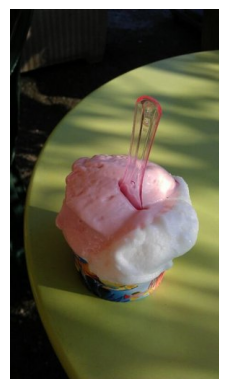

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt

image_paths = [
	image_path
	for class_name in class_names
	for image_path in (Path(train_dir) / class_name).iterdir()
	if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
]

random_image_path = random.choice(image_paths)
random_image = plt.imread(random_image_path)
print(f"Image shape: {random_image.shape}")
plt.imshow(random_image)
plt.axis("off");

Image shape: (287, 512, 3)


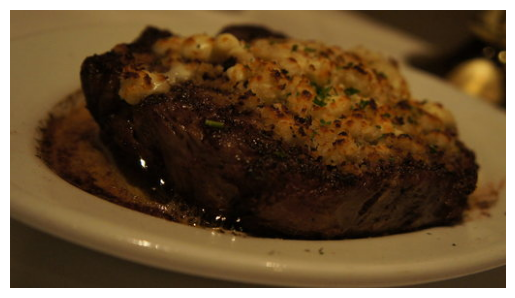

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt

image_paths = [
	image_path
	for class_name in class_names
	for image_path in (Path(train_dir) / class_name).iterdir()
	if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
]

random_image_path = random.choice(image_paths)
random_image = plt.imread(random_image_path)
print(f"Image shape: {random_image.shape}")
plt.imshow(random_image)
plt.axis("off");

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

# Create our model (a clone of model_8, except to be multi-class)
model_9 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(10, activation='softmax') # changed to have 10 neurons (same as number of classes) and 'softmax' activation
])

# Compile the model
model_9.compile(loss="categorical_crossentropy", # changed to categorical_crossentropy
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_9 = model_9.fit(train_data, # now 10 different classes 
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

NameError: name 'train_data' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale the data and create data generator instances
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='categorical') # changed to categorical

test_data = train_datagen.flow_from_directory(test_dir,
                                              target_size=(224, 224),
                                              batch_size=32,
                                              class_mode='categorical')

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

# Create our model (a clone of model_8, except to be multi-class)
model_9 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(10, activation='softmax') # changed to have 10 neurons (same as number of classes) and 'softmax' activation
])

# Compile the model
model_9.compile(loss="categorical_crossentropy", # changed to categorical_crossentropy
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
history_9 = model_9.fit(train_data, # now 10 different classes 
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 121s 509ms/step - accuracy: 0.2013 - loss: 2.1659 - val_accuracy: 0.2724 - val_loss: 2.0258
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 69s 294ms/step - accuracy: 0.3344 - loss: 1.9088 - val_accuracy: 0.3340 - val_loss: 1.8914
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 60s 255ms/step - accuracy: 0.4512 - loss: 1.6110 - val_accuracy: 0.3320 - val_loss: 1.9016
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 70s 297ms/step - accuracy: 0.6364 - loss: 1.1007 - val_accuracy: 0.3132 - val_loss: 2.1842
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 66s 282ms/step - accuracy: 0.8397 - loss: 0.5164 - val_accuracy: 0.2920 - val_loss: 2.9346


In [ ]:
def plot_history(history):
  """Plot training and validation accuracy and loss from a Keras History."""
  history_data = history.history
  epochs = range(1, len(history_data["loss"]) + 1)
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  for axis, metric, title in zip(axes, ("accuracy", "loss"), ("Accuracy", "Loss")):
    axis.plot(epochs, history_data[metric], label=f"Training {title.lower()}")
    validation_metric = f"val_{metric}"
    if validation_metric in history_data:
      axis.plot(epochs, history_data[validation_metric], label=f"Validation {title.lower()}")
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel(title)
    axis.legend()

  fig.tight_layout()
  plt.show()

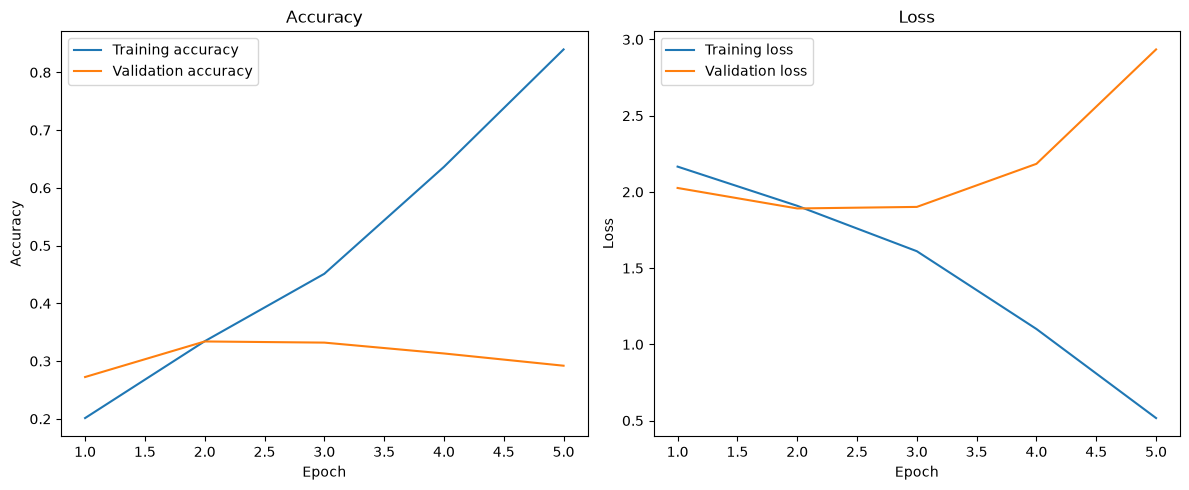

In [ ]:
plot_history(history_9)

In [ ]:
# Create augmented data generator instance
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=20, # note: this is an int not a float
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True)

train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                  target_size=(224, 224),
                                                                  batch_size=32,
                                                                  class_mode='categorical')

Found 7500 images belonging to 10 classes.


In [ ]:
# Clone the model (use the same architecture)
model_11 = tf.keras.models.clone_model(model_9)

# Compile the cloned model (same setup as used for model_10)
model_11.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [ ]:
# Fit the model
history_11 = model_11.fit(train_data_augmented, # use augmented data
                          epochs=5,
                          steps_per_epoch=len(train_data_augmented),
                          validation_data=test_data,
                          validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 135s 568ms/step - accuracy: 0.1849 - loss: 2.2108 - val_accuracy: 0.2468 - val_loss: 2.0594
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 600ms/step - accuracy: 0.2425 - loss: 2.0971 - val_accuracy: 0.3064 - val_loss: 1.9381
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 609ms/step - accuracy: 0.2803 - loss: 2.0425 - val_accuracy: 0.3412 - val_loss: 1.9096
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 145s 616ms/step - accuracy: 0.2975 - loss: 1.9942 - val_accuracy: 0.3328 - val_loss: 1.9097
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 146s 621ms/step - accuracy: 0.3160 - loss: 1.9675 - val_accuracy: 0.3764 - val_loss: 1.8173


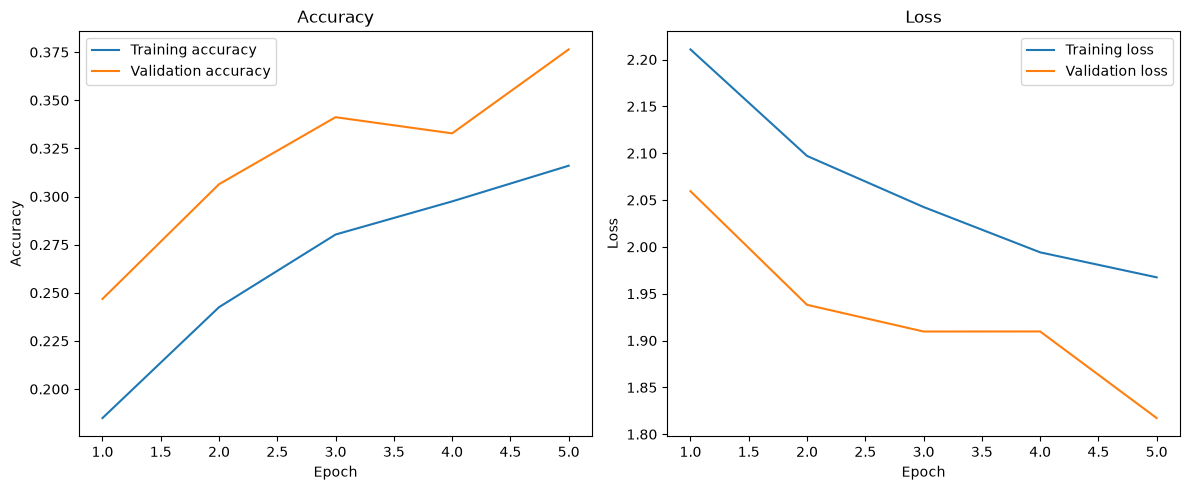

In [ ]:
plot_history(history_11)

In [ ]:
class_names = {index: name for name, index in train_data.class_indices.items()}
for image_path in Path("images").iterdir():
  if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif"}:
    image = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    image = tf.keras.utils.img_to_array(image) / 255.0
    prediction = model_11.predict(image[None, ...], verbose=0)[0]
    print(f"{image_path.name}: {class_names[prediction.argmax()]}")

03-hamburger.jpeg: pizza
03-pizza-dad.jpeg: pizza
03-steak.jpeg: grilled_salmon
03-sushi.jpeg: pizza
penne-pasta-tomato-sauce-with-chicken-tomatoes-wooden-table.jpg: chicken_wings
pre-prepared-food-showcasing-ready-eat-delicious-meals-go.jpg: steak


In [ ]:
class_names = {index: name for name, index in train_data.class_indices.items()}
images_dir = Path("images")
image_paths = [
    image_path for image_path in images_dir.iterdir()
    if image_path.is_file() and image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
] if images_dir.exists() else []

if not image_paths:
    print(f"No image files found in '{images_dir}'. Create an 'images' folder with test images first.")
else:
    for image_path in image_paths:
        image = tf.keras.utils.load_img(image_path, target_size=(224, 224))
        image = tf.keras.utils.img_to_array(image) / 255.0
        prediction = model_11.predict(tf.expand_dims(image, axis=0), verbose=0)[0]
        pred_index = int(tf.argmax(prediction).numpy())
        pred_class = class_names[pred_index]
        pred_confidence = float(prediction[pred_index])
        print(f"{image_path.name}: {pred_class} ({pred_confidence:.2%})")

03-hamburger.jpeg: pizza (17.15%)
03-pizza-dad.jpeg: pizza (21.69%)
03-steak.jpeg: grilled_salmon (24.80%)
03-sushi.jpeg: pizza (22.69%)
penne-pasta-tomato-sauce-with-chicken-tomatoes-wooden-table.jpg: chicken_wings (21.52%)
pre-prepared-food-showcasing-ready-eat-delicious-meals-go.jpg: steak (32.45%)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale the data and create data generator instances
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='categorical',
                                               shuffle=True)

test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode='categorical',
                                             shuffle=False)

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [ ]:
# Clone the model (use the same architecture)
model_11 = tf.keras.models.clone_model(model_9)

# Compile the cloned model (same setup as used for model_10)
model_11.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [ ]:
# Create augmented data generator instance
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=20, # note: this is an int not a float
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True)

train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                  target_size=(224, 224),
                                                                  batch_size=32,
                                                                  class_mode='categorical')

Found 7500 images belonging to 10 classes.


In [ ]:
# Create augmented data generator instance
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=20, # note: this is an int not a float
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True)

train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                  target_size=(224, 224),
                                                                  batch_size=32,
                                                                  class_mode='categorical')

Found 7500 images belonging to 10 classes.


In [ ]:
# Clone the model (use the same architecture)
model_11 = tf.keras.models.clone_model(model_9)

# Compile the cloned model (same setup as used for model_10)
model_11.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [ ]:
# Fit the model
history_11 = model_11.fit(train_data_augmented, # use augmented data
                          epochs=5,
                          steps_per_epoch=len(train_data_augmented),
                          validation_data=test_data,
                          validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 136s 574ms/step - accuracy: 0.2139 - loss: 2.1635 - val_accuracy: 0.2464 - val_loss: 2.0603
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 567ms/step - accuracy: 0.2805 - loss: 2.0417 - val_accuracy: 0.3432 - val_loss: 1.8565
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 145s 617ms/step - accuracy: 0.3132 - loss: 1.9748 - val_accuracy: 0.3808 - val_loss: 1.7932
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 146s 623ms/step - accuracy: 0.3295 - loss: 1.9320 - val_accuracy: 0.3500 - val_loss: 1.8559
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 140s 597ms/step - accuracy: 0.3528 - loss: 1.8835 - val_accuracy: 0.3976 - val_loss: 1.7665


In [ ]:
class_names = {index: name for name, index in train_data.class_indices.items()}
images_dir = Path("images")
image_paths = [
    image_path for image_path in images_dir.iterdir()
    if image_path.is_file() and image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
] if images_dir.exists() else []

if not image_paths:
    print(f"No image files found in '{images_dir}'. Create an 'images' folder with test images first.")
else:
    for image_path in image_paths:
        image = tf.keras.utils.load_img(image_path, target_size=(224, 224))
        image = tf.keras.utils.img_to_array(image) / 255.0
        prediction = model_11.predict(tf.expand_dims(image, axis=0), verbose=0)[0]
        pred_index = int(tf.argmax(prediction).numpy())
        pred_class = class_names[pred_index]
        pred_confidence = float(prediction[pred_index])
        print(f"{image_path.name}: {pred_class} ({pred_confidence:.2%})")

03-hamburger.jpeg: steak (21.02%)
03-pizza-dad.jpeg: pizza (30.96%)
03-steak.jpeg: steak (22.31%)
03-sushi.jpeg: chicken_curry (23.62%)
chicken_curry_sample.jpg: chicken_curry (65.50%)
chicken_wings_sample.jpg: chicken_curry (32.47%)
fried_rice_sample.jpg: fried_rice (41.04%)
grilled_salmon_sample.jpg: ice_cream (22.48%)
hamburger_sample.jpg: steak (48.18%)
ice_cream_sample.jpg: steak (47.78%)
pizza_sample.jpg: pizza (38.87%)
ramen_sample.jpg: ramen (59.04%)
steak_sample.jpg: ramen (30.89%)
sushi_sample.jpg: grilled_salmon (21.77%)
web_chicken_curry.jpg: pizza (22.64%)
web_chicken_wings.jpg: steak (64.78%)
web_fried_rice.jpg: fried_rice (28.80%)
web_grilled_salmon.jpg: ramen (25.80%)
web_hamburger.jpg: hamburger (29.59%)
web_ice_cream.jpg: ramen (26.92%)
web_pizza.jpg: ramen (38.66%)
web_ramen.jpg: ramen (48.57%)
web_steak.jpg: steak (34.26%)
web_sushi.jpg: pizza (37.39%)
